# 03 - Modelling

**Goal:** Build baseline models, train XGBoost, tune hyperparameters, and evaluate with walk-forward validation.

## 1. Setup

In [96]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from evaluate import evaluate, walk_forward_validation

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Load Feature-Engineered Data

In [97]:
df = pd.read_csv('../data/features_dataset.csv', parse_dates=['time'])
print('Shape:', df.shape)
df.head(3)

Shape: (34860, 89)


,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,total load actual_rolling_mean_24,total load actual_rolling_std_24,total load actual_rolling_mean_168,total load actual_rolling_std_168,is_holiday,is_holiday_or_weekend,heating_need,cooling_need,temp_range,wind_chill_proxy
0,2015-01-08 05:00:00,533.0,367.0,0.0,3946.0,5785.0,354.0,0.0,0.0,0.0,...,31258.416667,4961.132969,26598.708333,4230.470995,0,0,16.305800,0.0,16.576,22.828120
1,2015-01-08 06:00:00,525.0,360.0,0.0,3890.0,5570.0,347.0,0.0,0.0,0.0,...,31073.375000,5204.055073,26581.839286,4240.976907,0,0,16.221800,0.0,16.476,22.710520
2,2015-01-08 07:00:00,529.0,457.0,0.0,4066.0,6289.0,332.0,0.0,0.0,0.0,...,30819.958333,5469.766027,26570.892857,4249.054573,0,0,16.484862,0.0,16.266,23.078807


## 3. Define Features and Target

For a true 24h-ahead forecast, we can only use information available at prediction time.
That means lags ≥ 24h (not 1h, 2h, 3h), plus time features and weather.

We define two feature sets to compare:
- **All features** — includes short lags (would need near-real-time data)
- **24h-ahead features** — only lags ≥ 24h (realistic deployment scenario)

In [98]:
TARGET = 'total load actual'

# Time features (always available ahead of time)
time_feats = ['hour', 'dayofweek', 'month', 'quarter', 'is_weekend', 'day_of_year']

# Lag features - split by availability
lag_cols_all = [c for c in df.columns if f'{TARGET}_lag_' in c]
lag_cols_24h = [c for c in lag_cols_all if int(c.split('_')[-1]) >= 24]

# Rolling features (all use shift(1), so the 24h+ ones are safe)
rolling_cols = [c for c in df.columns if f'{TARGET}_rolling_' in c]

# Weather features
weather_feats = [c for c in df.columns if any(
    c.startswith(p) for p in ['temp_', 'pressure_', 'humidity_', 'wind_speed_',
                               'wind_deg_', 'rain_', 'snow_', 'clouds_all_',
                               'heating_need', 'cooling_need', 'temp_range', 'wind_chill']
)]

# Feature sets
features_all = time_feats + lag_cols_all + rolling_cols + weather_feats
features_24h = time_feats + lag_cols_24h + rolling_cols + weather_feats

# Deduplicate and filter to what exists
features_all = list(dict.fromkeys([f for f in features_all if f in df.columns]))
features_24h = list(dict.fromkeys([f for f in features_24h if f in df.columns]))

# Features with no weather features but with weather forecast ones
features_gen_forecast = time_feats + lag_cols_24h + rolling_cols + [
    'forecast solar day ahead',
    'forecast wind onshore day ahead',
]

# Features with all features plus forecast ones
features_combined = features_24h + [
    'forecast solar day ahead',
    'forecast wind onshore day ahead',
]

# Features with holidays
features_holiday = features_gen_forecast + ['is_holiday', 'is_holiday_or_weekend']
features_holiday = [f for f in features_holiday if f in df.columns]

print(f'All features:          {len(features_all)}')
print(f'24h-ahead features:    {len(features_24h)}')
print(f'Gen forecast features: {len(features_gen_forecast)}')
print(f'Combined features:     {len(features_combined)}')
print(f'Holiday features: {len(features_holiday)}')

All features:          57
24h-ahead features:    54
Gen forecast features: 19
Combined features:     56
Holiday features: 21


## 4. Train/Test Split (Temporal)

In [99]:
# Last 3 months as held-out test set
split_date = df['time'].max() - pd.Timedelta(days=90)

train_df = df[df['time'] < split_date].copy()
test_df = df[df['time'] >= split_date].copy()

print(f'Train: {len(train_df):,} rows  ({train_df["time"].min().date()} → {train_df["time"].max().date()})')
print(f'Test:  {len(test_df):,} rows  ({test_df["time"].min().date()} → {test_df["time"].max().date()})')

X_train = train_df[features_24h]
y_train = train_df[TARGET]
X_test = test_df[features_24h]
y_test = test_df[TARGET].values

Train: 32,699 rows  (2015-01-08 → 2018-10-02)
Test:  2,161 rows  (2018-10-02 → 2018-12-31)


## 5. Baseline Models

Three simple baselines to beat:
1. **Naive** - predict the value from 24 hours ago
2. **Seasonal naive** - predict the value from exactly 1 week ago
3. **7-day rolling mean** - average of the last 7 days

In [100]:
baselines = {
    'Naive (24h ago)': test_df[f'{TARGET}_lag_24'].values,
    'Seasonal Naive (1 week)': test_df[f'{TARGET}_lag_168'].values,
    '7-day Rolling Mean': test_df[f'{TARGET}_rolling_mean_168'].values,
}

baseline_results = []
for name, preds in baselines.items():
    mask = ~np.isnan(preds)
    result = evaluate(y_test[mask], preds[mask], model_name=name)
    baseline_results.append(result)

baseline_df = pd.DataFrame(baseline_results).set_index('model')
print('\n=== Baseline Comparison ===')
baseline_df


Naive (24h ago):
  MAE:  2382.6
  RMSE: 3438.4
  MAPE: 8.35%

Seasonal Naive (1 week):
  MAE:  2577.54
  RMSE: 3796.63
  MAPE: 9.06%

7-day Rolling Mean:
  MAE:  3956.43
  RMSE: 4553.49
  MAPE: 14.49%

=== Baseline Comparison ===


,MAE,RMSE,MAPE
model,,,
Naive (24h ago),2382.60,3438.40,8.35
Seasonal Naive (1 week),2577.54,3796.63,9.06
7-day Rolling Mean,3956.43,4553.49,14.49


## 6. XGBoost - Default Parameters

In [101]:
model_default = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=20,
)

model_default.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

preds_default = model_default.predict(X_test)
result_default = evaluate(y_test, preds_default, model_name='XGBoost (default)')

[0]	validation_0-rmse:4242.83667
[50]	validation_0-rmse:868.92055
[100]	validation_0-rmse:801.07799
[150]	validation_0-rmse:771.69718
[200]	validation_0-rmse:754.63951
[250]	validation_0-rmse:749.45882
[300]	validation_0-rmse:741.06791
[350]	validation_0-rmse:737.80008
[400]	validation_0-rmse:732.91394
[450]	validation_0-rmse:729.45688
[464]	validation_0-rmse:729.96385

XGBoost (default):
  MAE:  491.83
  RMSE: 728.58
  MAPE: 1.76%


## 7. Feature Importance

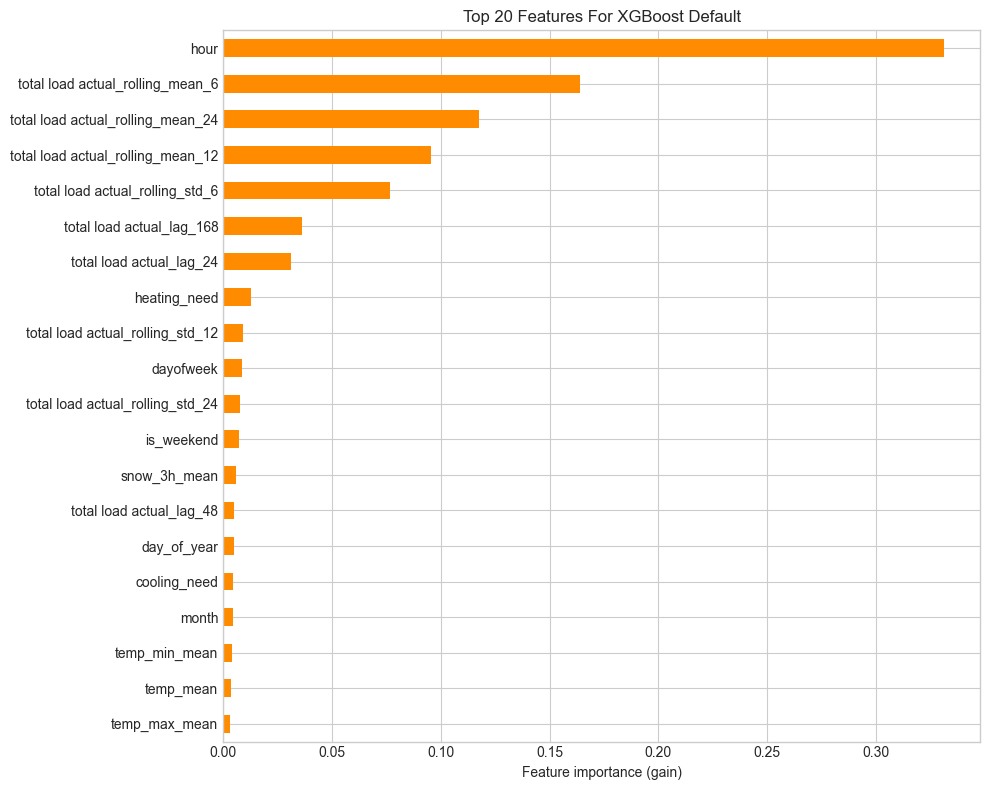

In [102]:
importance = pd.Series(
    model_default.feature_importances_,
    index=features_24h
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importance.head(20).plot.barh(ax=ax, color='darkorange')
ax.set_xlabel('Feature importance (gain)')
ax.set_title('Top 20 Features For XGBoost Default')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning

Grid search with `TimeSeriesSplit` to respect temporal ordering.
This can take 10-30 minutes — reduce the grid if you need faster results.

In [103]:
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 500, 800],
    'subsample': [0.7, 0.9],
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search = GridSearchCV(
    xgb.XGBRegressor(colsample_bytree=0.8, random_state=42, n_jobs=-1),
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=1,
)

grid_search.fit(X_train, y_train)

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best CV MAE: {-grid_search.best_score_:.2f}')

Fitting 3 folds for each of 54 candidates, totalling 162 fits

Best params: {'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 800, 'subsample': 0.9}
Best CV MAE: 572.88


## 9. Evaluate Tuned Model

In [104]:
best_model = grid_search.best_estimator_
preds_tuned = best_model.predict(X_test)
result_tuned = evaluate(y_test, preds_tuned, model_name='XGBoost (tuned)')

all_results = baseline_df.copy()
all_results.loc['XGBoost (default)'] = result_default
all_results.loc['XGBoost (tuned)'] = result_tuned
# Drop the model name column if it exists from evaluate()
if 'model' in all_results.columns:
    all_results = all_results.drop(columns=['model'])

print('\n=== All Models Comparison ===')
all_results


XGBoost (tuned):
  MAE:  457.92
  RMSE: 696.17
  MAPE: 1.64%

=== All Models Comparison ===


,MAE,RMSE,MAPE
model,,,
Naive (24h ago),2382.60,3438.40,8.35
Seasonal Naive (1 week),2577.54,3796.63,9.06
7-day Rolling Mean,3956.43,4553.49,14.49
XGBoost (default),491.83,728.58,1.76
XGBoost (tuned),457.92,696.17,1.64


## 10. Other Models

### LightGBM

In [105]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=800,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

lgb_model.fit(X_train, y_train)
preds_lgb = lgb_model.predict(X_test)
result_lgb = evaluate(y_test, preds_lgb, model_name='LightGBM')


LightGBM:
  MAE:  488.36
  RMSE: 732.81
  MAPE: 1.75%


In [106]:
all_results.loc['LightGBM'] = result_lgb
if 'model' in all_results.columns:
    all_results = all_results.drop(columns=['model'])

print('\n=== All Models Comparison ===')
all_results


=== All Models Comparison ===


,MAE,RMSE,MAPE
model,,,
Naive (24h ago),2382.60,3438.40,8.35
Seasonal Naive (1 week),2577.54,3796.63,9.06
7-day Rolling Mean,3956.43,4553.49,14.49
XGBoost (default),491.83,728.58,1.76
XGBoost (tuned),457.92,696.17,1.64
LightGBM,488.36,732.81,1.75


### Random Forest Model

In [107]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
preds_rf = rf_model.predict(X_test)
result_rf = evaluate(y_test, preds_rf, model_name='Random Forest')

all_results.loc['Random Forest'] = result_rf
if 'model' in all_results.columns:
    all_results = all_results.drop(columns=['model'])

all_results


Random Forest:
  MAE:  523.44
  RMSE: 797.39
  MAPE: 1.87%


,MAE,RMSE,MAPE
model,,,
Naive (24h ago),2382.60,3438.40,8.35
Seasonal Naive (1 week),2577.54,3796.63,9.06
7-day Rolling Mean,3956.43,4553.49,14.49
XGBoost (default),491.83,728.58,1.76
XGBoost (tuned),457.92,696.17,1.64
LightGBM,488.36,732.81,1.75
Random Forest,523.44,797.39,1.87


### TSO (Red Eléctrica) forecast comparison

In [108]:
tso_preds = test_df['total load forecast'].values
mask = ~np.isnan(tso_preds)
result_tso = evaluate(y_test[mask], tso_preds[mask], model_name='TSO Forecast')

all_results.loc['TSO Forecast'] = result_tso
if 'model' in all_results.columns:
    all_results = all_results.drop(columns=['model'])

print('\n=== All Models Comparison (including TSO) ===')
all_results


TSO Forecast:
  MAE:  248.83
  RMSE: 339.9
  MAPE: 0.87%

=== All Models Comparison (including TSO) ===


,MAE,RMSE,MAPE
model,,,
Naive (24h ago),2382.60,3438.40,8.35
Seasonal Naive (1 week),2577.54,3796.63,9.06
7-day Rolling Mean,3956.43,4553.49,14.49
XGBoost (default),491.83,728.58,1.76
XGBoost (tuned),457.92,696.17,1.64
LightGBM,488.36,732.81,1.75
Random Forest,523.44,797.39,1.87
TSO Forecast,248.83,339.90,0.87


### Weather vs Generation Forecast Comparison

In [109]:
ablation_results = {}

for name, feats in [('A: Weather only', features_24h),
                     ('B: Gen forecasts only', features_gen_forecast),
                     ('C: Both combined', features_combined)]:
    
    X_tr = train_df[feats]
    X_te = test_df[feats]
    
    m = xgb.XGBRegressor(**grid_search.best_params_, random_state=42, n_jobs=-1)
    m.fit(X_tr, y_train, verbose=False)
    preds = m.predict(X_te)
    result = evaluate(y_test, preds, model_name=name)
    ablation_results[name] = result

ablation_df = pd.DataFrame(ablation_results).T
if 'model' in ablation_df.columns:
    ablation_df = ablation_df.drop(columns=['model'])

print('\n=== Weather vs Generation Forecast Comparison ===')
ablation_df


A: Weather only:
  MAE:  460.4
  RMSE: 702.0
  MAPE: 1.65%

B: Gen forecasts only:
  MAE:  414.83
  RMSE: 634.62
  MAPE: 1.48%

C: Both combined:
  MAE:  428.78
  RMSE: 650.67
  MAPE: 1.54%

=== Weather vs Generation Forecast Comparison ===


,MAE,RMSE,MAPE
A: Weather only,460.4,702.0,1.65
B: Gen forecasts only,414.83,634.62,1.48
C: Both combined,428.78,650.67,1.54


Generation forecasts alone (B) beat weather features alone (A). 1.48% vs 1.65% MAPE. The solar and wind day-ahead forecasts are more informative than the raw weather variables.

Combining both (C) is worse than generation forecasts alone (B). 1.54% vs 1.48%. Adding weather features on top of generation forecasts actually hurts slightly. This suggests the weather features are adding noise. Maybe features could be improved.

In [110]:
all_results.loc['XGBoost (gen forecasts)'] = ablation_results['B: Gen forecasts only']
if 'model' in all_results.columns:
    all_results = all_results.drop(columns=['model'])

print('\n=== Updated Model Comparison ===')
all_results


=== Updated Model Comparison ===


,MAE,RMSE,MAPE
model,,,
Naive (24h ago),2382.60,3438.40,8.35
Seasonal Naive (1 week),2577.54,3796.63,9.06
7-day Rolling Mean,3956.43,4553.49,14.49
XGBoost (default),491.83,728.58,1.76
XGBoost (tuned),457.92,696.17,1.64
LightGBM,488.36,732.81,1.75
Random Forest,523.44,797.39,1.87
TSO Forecast,248.83,339.90,0.87
XGBoost (gen forecasts),414.83,634.62,1.48


### Holiday Feature Impact

In [111]:
m_no_holiday = xgb.XGBRegressor(**grid_search.best_params_, random_state=42, n_jobs=-1)
m_no_holiday.fit(train_df[features_gen_forecast], y_train, verbose=False)
preds_no = m_no_holiday.predict(test_df[features_gen_forecast])
result_no = evaluate(y_test, preds_no, model_name='Without holidays')

m_holiday = xgb.XGBRegressor(**grid_search.best_params_, random_state=42, n_jobs=-1)
m_holiday.fit(train_df[features_holiday], y_train, verbose=False)
preds_hol = m_holiday.predict(test_df[features_holiday])
result_hol = evaluate(y_test, preds_hol, model_name='With holidays')


Without holidays:
  MAE:  414.83
  RMSE: 634.62
  MAPE: 1.48%

With holidays:
  MAE:  411.27
  RMSE: 636.71
  MAPE: 1.47%


In [112]:
holiday_mask = test_df['is_holiday'] == 1

print(f'Holiday hours: {holiday_mask.sum()}')
print(f'MAE on holidays (without): {np.abs(y_test[holiday_mask] - preds_no[holiday_mask]).mean():.1f}')
print(f'MAE on holidays (with):    {np.abs(y_test[holiday_mask] - preds_hol[holiday_mask]).mean():.1f}')
print(f'MAE on non-holidays (without): {np.abs(y_test[~holiday_mask] - preds_no[~holiday_mask]).mean():.1f}')
print(f'MAE on non-holidays (with):    {np.abs(y_test[~holiday_mask] - preds_hol[~holiday_mask]).mean():.1f}')

Holiday hours: 120
MAE on holidays (without): 581.7
MAE on holidays (with):    615.9
MAE on non-holidays (without): 405.0
MAE on non-holidays (with):    399.2


### Feature Importance For Improved XGBoost

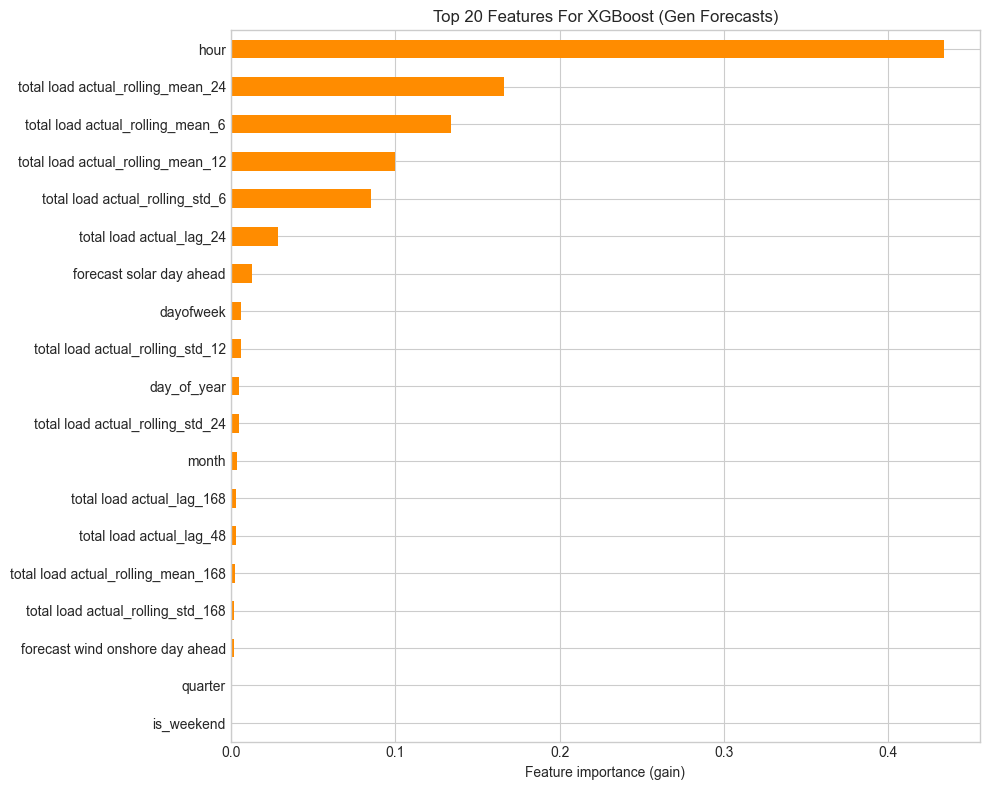

In [113]:
m_gen = xgb.XGBRegressor(**grid_search.best_params_, random_state=42, n_jobs=-1)
m_gen.fit(train_df[features_gen_forecast], y_train, verbose=False)

importance_gen = pd.Series(
    m_gen.feature_importances_,
    index=features_gen_forecast
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
importance_gen.head(20).plot.barh(ax=ax, color='darkorange')
ax.set_xlabel('Feature importance (gain)')
ax.set_title('Top 20 Features For XGBoost (Gen Forecasts)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 11. Walk-Forward Validation

Uses `walk_forward_validation` from `src/evaluate.py` - expanding window, train on N months, test on the next month, step forward.

In [114]:
df_wf = df.dropna(subset=features_gen_forecast + [TARGET]).copy()
df_wf = df_wf.set_index('time')

wf_model = xgb.XGBRegressor(**grid_search.best_params_, random_state=42, n_jobs=-1)

wf_results = walk_forward_validation(
    df_wf,
    feature_cols=features_24h,
    target_col=TARGET,
    model=wf_model,
    train_months=12,
    test_months=1,
    step_months=1,
)

print(f'Walk-forward produced {wf_results["fold"].nunique()} folds')
print(f'Total predictions: {len(wf_results):,}')

Walk-forward produced 35 folds
Total predictions: 25,551


In [115]:
fold_metrics = []
for fold_id in sorted(wf_results['fold'].unique()):
    fold_data = wf_results[wf_results['fold'] == fold_id]
    result = evaluate(fold_data['actual'], fold_data['predicted'], model_name=f'Fold {fold_id}')
    result['n_samples'] = len(fold_data)
    result['start'] = fold_data.index.min()
    result['end'] = fold_data.index.max()
    fold_metrics.append(result)

fold_df = pd.DataFrame(fold_metrics)
print('\n=== Walk-Forward Results by Fold ===')
fold_df[['model', 'MAE', 'RMSE', 'MAPE', 'n_samples', 'start', 'end']]


Fold 0:
  MAE:  563.7
  RMSE: 796.57
  MAPE: 2.01%

Fold 1:
  MAE:  565.69
  RMSE: 794.96
  MAPE: 2.04%

Fold 2:
  MAE:  654.87
  RMSE: 926.64
  MAPE: 2.36%

Fold 3:
  MAE:  607.57
  RMSE: 898.55
  MAPE: 2.19%

Fold 4:
  MAE:  528.57
  RMSE: 800.82
  MAPE: 1.95%

Fold 5:
  MAE:  576.68
  RMSE: 858.23
  MAPE: 2.05%

Fold 6:
  MAE:  598.61
  RMSE: 885.25
  MAPE: 2.07%

Fold 7:
  MAE:  562.06
  RMSE: 828.49
  MAPE: 2.02%

Fold 8:
  MAE:  536.41
  RMSE: 769.89
  MAPE: 1.96%

Fold 9:
  MAE:  588.0
  RMSE: 857.81
  MAPE: 2.17%

Fold 10:
  MAE:  519.46
  RMSE: 761.05
  MAPE: 1.84%

Fold 11:
  MAE:  664.68
  RMSE: 905.56
  MAPE: 2.46%

Fold 12:
  MAE:  643.27
  RMSE: 897.19
  MAPE: 2.18%

Fold 13:
  MAE:  522.87
  RMSE: 778.59
  MAPE: 1.83%

Fold 14:
  MAE:  582.67
  RMSE: 827.24
  MAPE: 2.06%

Fold 15:
  MAE:  644.98
  RMSE: 983.44
  MAPE: 2.53%

Fold 16:
  MAE:  491.71
  RMSE: 749.77
  MAPE: 1.81%

Fold 17:
  MAE:  618.28
  RMSE: 871.7
  MAPE: 2.1%

Fold 18:
  MAE:  540.11
  RMSE: 768.12
  

,model,MAE,RMSE,MAPE,n_samples,start,end
0,Fold 0,563.70,796.57,2.01,744,2016-01-08 05:00:00,2016-02-08 04:00:00
1,Fold 1,565.69,794.96,2.04,696,2016-02-08 05:00:00,2016-03-08 04:00:00
2,Fold 2,654.87,926.64,2.36,744,2016-03-08 05:00:00,2016-04-08 04:00:00
3,Fold 3,607.57,898.55,2.19,718,2016-04-08 05:00:00,2016-05-08 04:00:00
4,Fold 4,528.57,800.82,1.95,743,2016-05-08 05:00:00,2016-06-08 04:00:00
5,Fold 5,576.68,858.23,2.05,720,2016-06-08 05:00:00,2016-07-08 04:00:00
6,Fold 6,598.61,885.25,2.07,743,2016-07-08 05:00:00,2016-08-08 04:00:00
7,Fold 7,562.06,828.49,2.02,744,2016-08-08 05:00:00,2016-09-08 04:00:00
8,Fold 8,536.41,769.89,1.96,719,2016-09-08 05:00:00,2016-10-08 04:00:00
9,Fold 9,588.00,857.81,2.17,744,2016-10-08 05:00:00,2016-11-08 04:00:00


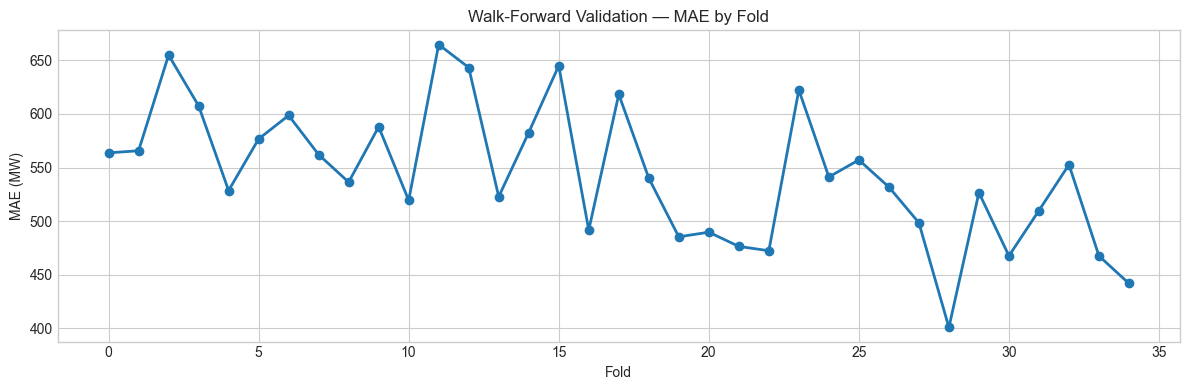

In [116]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(fold_df)), fold_df['MAE'], marker='o', linewidth=2)
ax.set_xlabel('Fold')
ax.set_ylabel('MAE (MW)')
ax.set_title('Walk-Forward Validation — MAE by Fold')
plt.tight_layout()
plt.show()

## 12. Save Best Model

In [118]:
with open('../data/best_xgb_model.pkl', 'wb') as f:
    pickle.dump(m_gen, f)

with open('../data/feature_columns.json', 'w') as f:
    json.dump(features_gen_forecast, f)

all_results.to_csv('../data/model_comparison.csv')

print('Saved: best_xgb_model.pkl, feature_columns.json, model_comparison.csv')

Saved: best_xgb_model.pkl, feature_columns.json, model_comparison.csv
